In [1]:
import openseespy.opensees as ops
import opsvis as opsv
import matplotlib.pyplot as plt

In [2]:
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)

In [3]:
# X-section Area
A = 0.1 # units
# Elasticity
E = 2.0e8 # units
# MOI of section
Iz = 0.001 # units
# length of beaam
Lb = 10. # units
# length of column
Lc = 10. # units
# horizontal load at node 2
P = 50. # units
# vertical UDL in element 2
P2 = -20 # units

In [4]:
# define nodes
ops.node(1, 0., 0.)
ops.node(2, 0., Lc)
ops.node(3, Lc, Lb)
ops.node(4, Lb, 0.)

<Axes: >

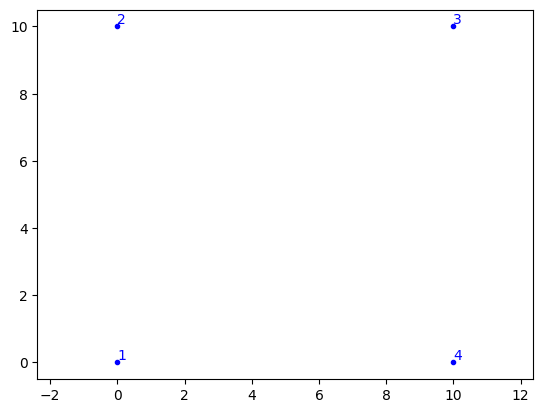

In [5]:
opsv.plot_model()

In [6]:
# boundary conditions
ops.fix(1, 1, 1, 1) # fixed
ops.fix(4, 1, 1, 1) # fixed

In [7]:
# element properties
ops.geomTransf('Linear', 1)
# ops.element(elementType, elemTag, iNode, jNode, Area, E, Iz, transTag)
ops.element('elasticBeamColumn', 1, 1, 2, A, E, Iz, 1)
ops.element('elasticBeamColumn', 2, 2, 3, A, E, Iz, 1)
ops.element('elasticBeamColumn', 3, 3, 4, A, E, Iz, 1)

<Axes: >

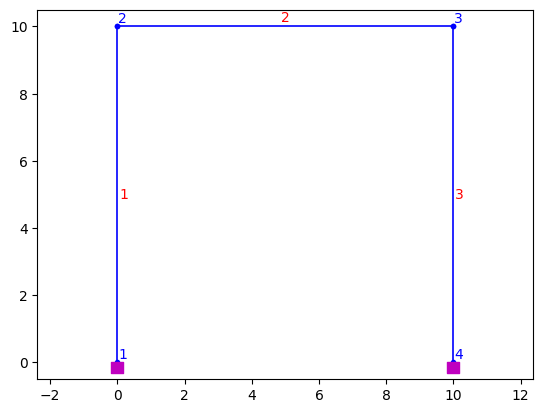

In [8]:
opsv.plot_model()

In [9]:
# loads
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(2, P, 0., 0.)

In [10]:
# UDL (Vertical on Beam Element 2)
# eleLoad('-ele', eleTag, '-type', '-beamUniform', Wy, Wx=0)
ops.eleLoad('-ele', 2, '-type', '-beamUniform', P2, 0.)

In [11]:
# analysis
ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.algorithm('Linear')
ops.integrator('LoadControl', 1.)
ops.analysis('Static')
ops.test('NormDispIncr', 1.0e-6, 10)

In [12]:
ops.analyze(1)

0

(np.float64(41.65417041554158), np.float64(41.65417041554158), <Axes: >)

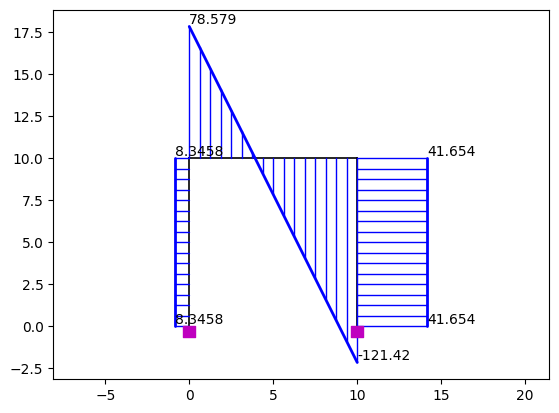

In [13]:
opsv.section_force_diagram_2d('V', sfac=0.1)

(np.float64(-218.17559198010883), np.float64(198.36611217530697), <Axes: >)

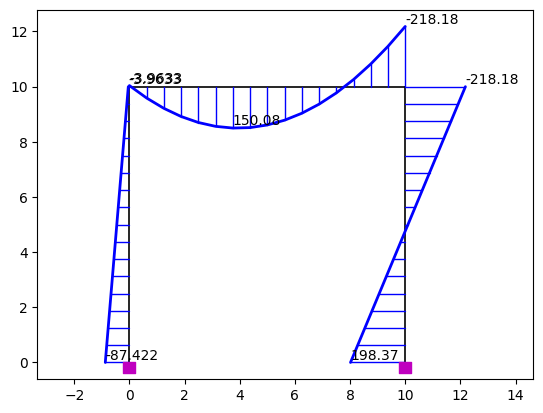

In [14]:
opsv.section_force_diagram_2d('M', sfac=0.01)

(np.float64(-121.42122700788262), np.float64(-121.42122700788262), <Axes: >)

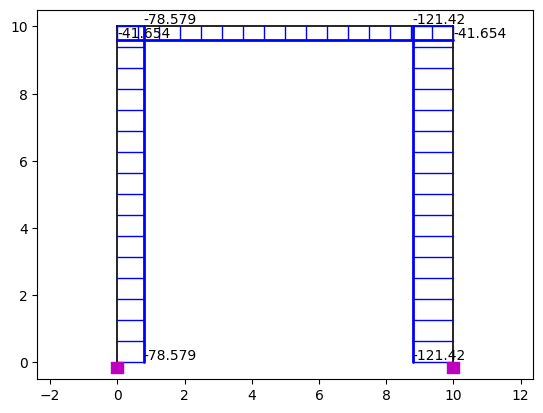

In [15]:
opsv.section_force_diagram_2d('N', sfac=0.01)

In [16]:
ops.reactions()
print(f"The reaction at node 1 is {ops.nodeReaction(1)}")
print(f"The reaction at node 4 is {ops.nodeReaction(4)}")

The reaction at node 1 is [-8.345829584457562, 78.57877299211735, 87.42161774585799]
The reaction at node 4 is [-41.654170415541586, 121.42122700788262, 198.36611217530697]


(np.float64(67.11163267701218), <Axes: >)

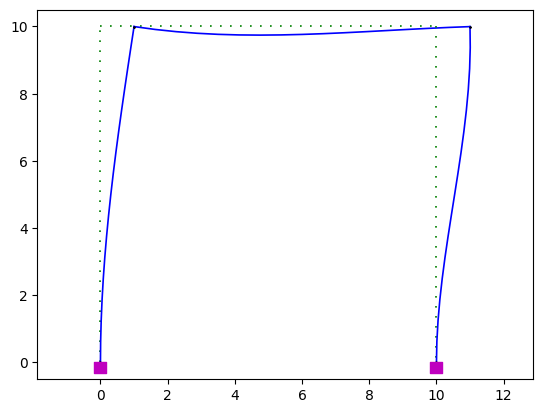

In [17]:
opsv.plot_defo()

<Axes: >

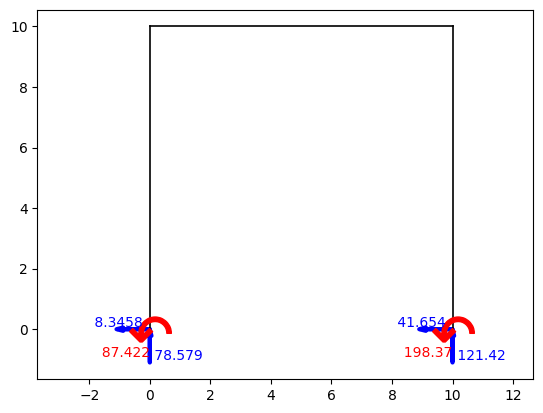

In [18]:
opsv.plot_reactions()

In [19]:
nodes_tag = ops.getNodeTags()
deflections = [abs(ops.nodeDisp(tag, 2)) for tag in nodes_tag]

In [20]:
deflections

[0.0, 3.928938649605868e-05, 6.0710613503941313e-05, 0.0]

In [21]:
print(f"The maximum displacement is {max(deflections)}")

The maximum displacement is 6.0710613503941313e-05
